# Practical case: steel structure reliability

Supporting notebook for the steel structure reliability case.

The dataset is retrieved from the public `HowToTeachSensitivityAnalysis` repository from the directory `case_studies/steel_reliability/datasets`. The notebook identifies the steel-reliability CSV from its expected model variables (`delta_sig`, `sigma_res`, `R`, `Rp0.2`, and `Kf`).





In [1]:
!pip install simdec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 9.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display


import json
from importlib.metadata import distribution, version

import simdec as sd

assert callable(getattr(sd, "sensitivity_indices", None))
assert callable(getattr(sd, "heterogeneity_indices", None))

dist = distribution("simdec")
print("SimDec version:", version("simdec"))
print("SimDec module:", sd.__file__)

direct_url = dist.read_text("direct_url.json")
if direct_url:
    print("Installation provenance:")
    print(json.dumps(json.loads(direct_url), indent=2))
else:
    print("No direct_url.json was found for this installation.")


N_REGIONS = 5
H_THRESHOLD = 0.10
S_THRESHOLD = 0.30
SI_COLOR = "#173F6D"
H_COLOR = "#8B3F3F"

SimDec version: 1.5.2
SimDec module: /usr/local/lib/python3.13/dist-packages/simdec/__init__.py
No direct_url.json was found for this installation.


In [3]:
# Steel-reliability dataset pinned to the source repository commit.
from urllib.request import Request, urlopen

DATA_REPO = "Sensitivity-Analysis-for-Model-Output/HowToTeachSensitivityAnalysis"
DATA_REF = "727cc4b6b1e89b344cdfabd2ae5c8338297b9dac"
DATA_DIR = "case_studies/steel_reliability/datasets"
DATA_PAGE = (
    f"https://github.com/{DATA_REPO}/tree/{DATA_REF}/{DATA_DIR}"
)
API_URL = (
    f"https://api.github.com/repos/{DATA_REPO}/contents/{DATA_DIR}"
    f"?ref={DATA_REF}"
)

request = Request(
    API_URL,
    headers={"User-Agent": "heterogeneity-supporting-material"},
)
with urlopen(request) as response:
    listing = json.load(response)

csv_files = [
    item for item in listing
    if item.get("type") == "file"
    and item.get("name", "").lower().endswith(".csv")
]

expected = {"delta_sig", "sigma_res", "R", "Rp0.2", "Kf"}
steel = None
source = None

for item in csv_files:
    candidate = pd.read_csv(item["download_url"])
    if expected.issubset(set(candidate.columns)):
        steel = candidate
        source = item["html_url"]
        break

if steel is None:
    names = [item["name"] for item in csv_files]
    raise FileNotFoundError(
        "Could not identify the steel-reliability dataset in "
        f"{DATA_PAGE}. CSV files found: {names}"
    )

steel = (
    steel.dropna(axis=0, how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

# Keep the published model order explicit.
steel = steel[["delta_sig", "sigma_res", "R", "Rp0.2", "Kf"]]
output_name = "delta_sig"
y_steel = pd.to_numeric(steel[output_name], errors="raise")
X_steel = steel[["sigma_res", "R", "Rp0.2", "Kf"]].copy()

for col in X_steel.columns:
    X_steel[col] = pd.to_numeric(X_steel[col], errors="raise")

if steel.isna().any().any():
    raise ValueError("Missing values are present in the steel dataset.")

print("Dataset directory:", DATA_PAGE)
print("Dataset file:", source)
print(
    "Observations:", len(steel),
    "Output:", output_name,
    "Inputs:", list(X_steel.columns),
)
display(steel.head())


Dataset directory: https://github.com/Sensitivity-Analysis-for-Model-Output/HowToTeachSensitivityAnalysis/tree/727cc4b6b1e89b344cdfabd2ae5c8338297b9dac/case_studies/steel_reliability/datasets
Dataset file: https://github.com/Sensitivity-Analysis-for-Model-Output/HowToTeachSensitivityAnalysis/blob/727cc4b6b1e89b344cdfabd2ae5c8338297b9dac/case_studies/steel_reliability/datasets/2_Steel_reliability_data.csv
Observations: 10000 Output: delta_sig Inputs: ['sigma_res', 'R', 'Rp0.2', 'Kf']


,delta_sig,sigma_res,R,Rp0.2,Kf
0,311.898918,-84.530638,-0.834480,297.406168,2.454866
1,500.044381,347.586947,-0.131827,379.499452,2.774116
2,715.171820,946.567040,-0.039126,940.477667,2.504617
3,482.477633,74.222224,0.440311,406.622486,2.466723
4,663.983635,-32.937734,0.419690,979.498038,2.615602


In [4]:
global_est = sd.sensitivity_indices(inputs=X_steel, output=y_steel)
global_si = pd.Series(np.asarray(global_est.si, dtype=float).ravel(), index=X_steel.columns, name="S_i")
H = sd.heterogeneity_indices(output=y_steel, inputs=X_steel, n_regions=N_REGIONS)
summary = pd.DataFrame({"S_i": global_si, "H_Xi": H.indices.reindex(X_steel.columns)})
display(summary.style.format("{:.4f}"))
print("H_Y:", H.indices["Y"])
print("Raw global SI sum:", global_si.sum())

,S_i,H_Xi
sigma_res,0.5168,0.4065
R,0.3503,0.3118
Rp0.2,0.0955,0.2379
Kf,0.0410,0.0443


H_Y: 0.3770661751962995
Raw global SI sum: 1.00361087420227


## Figure 12

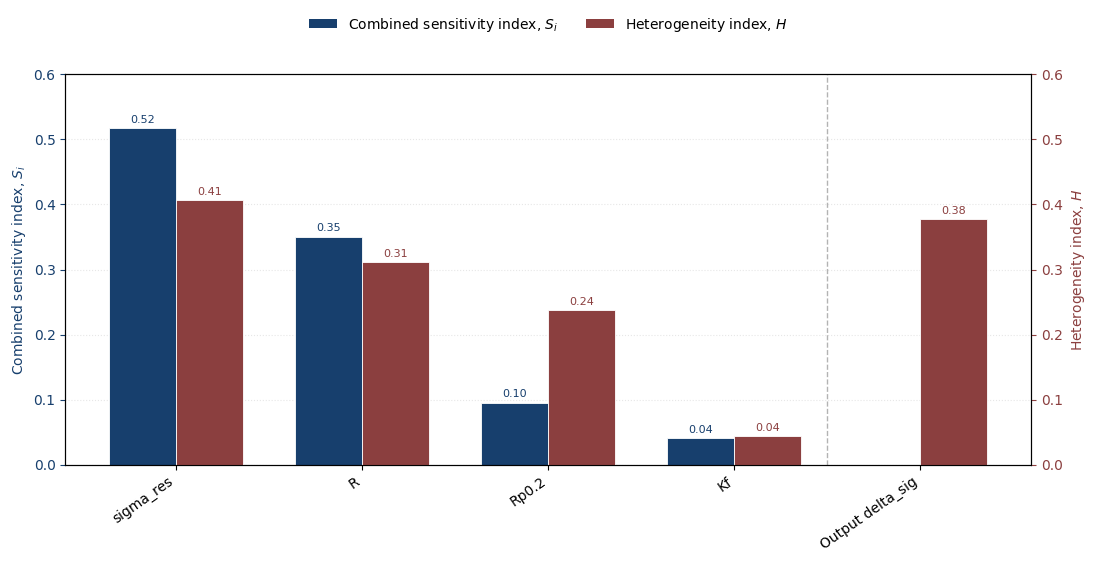

In [5]:
order = global_si.sort_values(ascending=False).index.tolist()
labels = order + [rf"Output {output_name}"]
S_plot = np.r_[global_si.loc[order].to_numpy(float), np.nan]
H_plot = np.r_[H.indices.loc[order].to_numpy(float), H.indices["Y"]]
x = np.arange(len(labels)); width=0.36
ymax = max(0.60, np.ceil((np.nanmax(np.r_[S_plot,H_plot])+0.08)*10)/10); ymax=min(ymax,1.0)
fig, ax_s = plt.subplots(figsize=(max(11.5,1.05*len(labels)),6.2)); ax_h=ax_s.twinx()
bs=ax_s.bar(x-width/2,S_plot,width,color=SI_COLOR,edgecolor="white",linewidth=0.6)
bh=ax_h.bar(x+width/2,H_plot,width,color=H_COLOR,edgecolor="white",linewidth=0.6)
ax_s.set_ylabel(r"Combined sensitivity index, $S_i$",color=SI_COLOR);ax_h.set_ylabel(r"Heterogeneity index, $H$",color=H_COLOR)
ax_s.set_ylim(0,ymax);ax_h.set_ylim(0,ymax);ax_s.tick_params(axis="y",colors=SI_COLOR);ax_h.tick_params(axis="y",colors=H_COLOR)
ax_s.set_xticks(x);ax_s.set_xticklabels(labels,rotation=35,ha="right");ax_s.axvline(len(order)-0.5,color="0.70",linestyle="--",linewidth=1)
ax_s.grid(axis="y",linestyle=":",alpha=0.30);ax_s.set_axisbelow(True)
for b,v in zip(bs,S_plot):
    if np.isfinite(v): ax_s.text(b.get_x()+b.get_width()/2,v+ymax*0.014,f"{v:.2f}",ha="center",fontsize=8,color=SI_COLOR)
for b,v in zip(bh,H_plot):
    if np.isfinite(v): ax_h.text(b.get_x()+b.get_width()/2,v+ymax*0.014,f"{v:.2f}",ha="center",fontsize=8,color=H_COLOR)
fig.legend(handles=[Patch(facecolor=SI_COLOR,label=r"Combined sensitivity index, $S_i$"),Patch(facecolor=H_COLOR,label=r"Heterogeneity index, $H$")],loc="upper center",bbox_to_anchor=(0.5,0.995),ncol=2,frameon=False)
fig.subplots_adjust(left=0.08,right=0.92,top=0.88,bottom=0.25)
plt.show()

Figure 12: Global combined sensitivity indices 𝑆𝑖 and heterogeneity indices for the steel structure reliability model.
Input-conditioned heterogeneity 𝐻𝑋𝑖 is shown alongside the corresponding global sensitivity index, while 𝐻𝑌
summarizes changes in sensitivity structure across the output distribution

## Figure 13

Selected profiles: ['Y', 'sigma_res', 'Rp0.2', 'R']


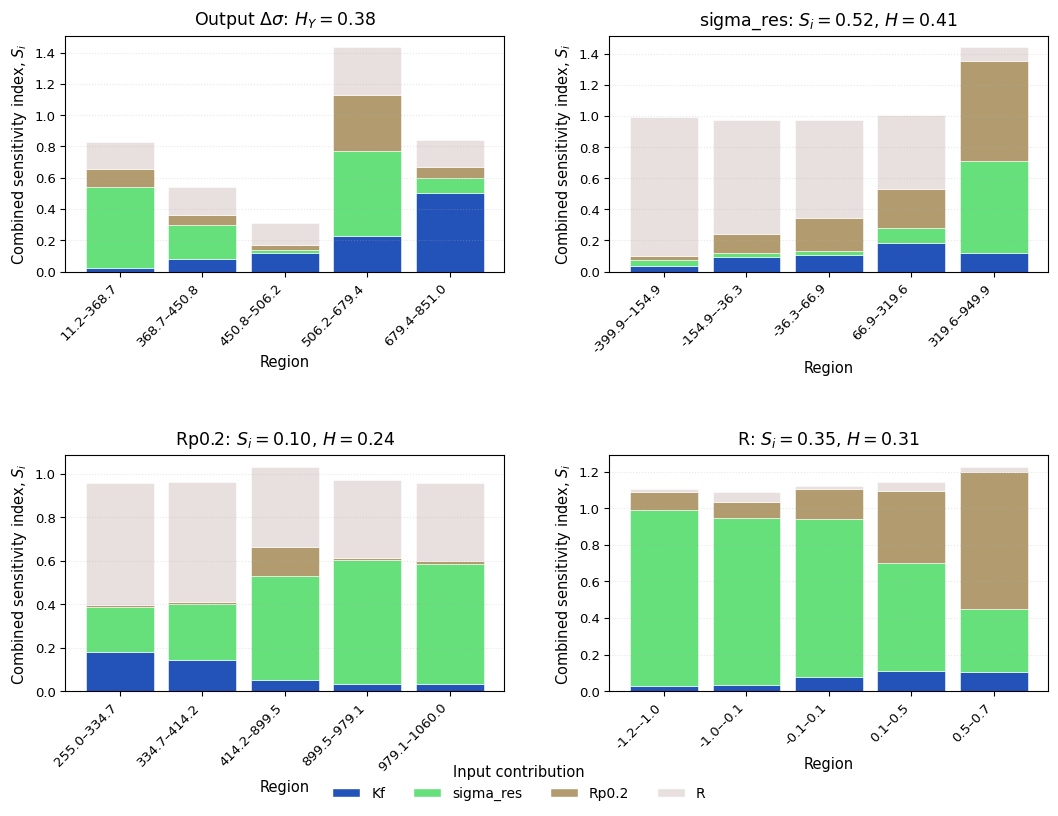

In [6]:
SELECTED = ["Y", "sigma_res", "Rp0.2", "R"]
PROFILE_ORDER = ["Kf", "sigma_res", "Rp0.2", "R"]

print("Selected profiles:", SELECTED)

cmap = plt.colormaps["terrain"]
colors = {
    name: cmap(pos)
    for name, pos in zip(
        PROFILE_ORDER,
        np.linspace(0.05, 0.95, len(PROFILE_ORDER)),
    )
}

def fmt(v):
    if isinstance(v, pd.Interval):
        return f"{v.left:.1f}–{v.right:.1f}"
    if isinstance(v, (int, float, np.integer, np.floating)):
        return f"{v:.1f}"
    return str(v)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.8, 8.4),
    squeeze=False,
)

axes = axes.ravel()

for ax, name in zip(axes, SELECTED):
    raw = H.details[name].raw_profiles.copy()

    # Force the same stacking order as in the manuscript.
    raw = raw.reindex(
        columns=[v for v in PROFILE_ORDER if v in raw.columns]
    )

    raw.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[colors[c] for c in raw.columns],
        edgecolor="white",
        linewidth=0.4,
        width=0.82,
        legend=False,
    )

    if name == "Y":
        title = rf"Output $\Delta\sigma$: $H_Y={H.indices['Y']:.2f}$"
    else:
        title = (
            rf"{name}: $S_i={global_si[name]:.2f}$, "
            rf"$H={H.indices[name]:.2f}$"
        )

    ax.set_title(title, fontsize=12.5, pad=8)
    ax.set_xlabel("Region", fontsize=10.5)
    ax.set_ylabel(
        r"Combined sensitivity index, $S_i$",
        fontsize=10.5,
    )

    ax.set_xticklabels(
        [fmt(v) for v in raw.index],
        rotation=45,
        ha="right",
        fontsize=9.5,
    )

    ax.tick_params(axis="y", labelsize=9.5)
    ax.grid(axis="y", linestyle=":", alpha=0.30)

fig.legend(
    handles=[
        Patch(
            facecolor=colors[name],
            edgecolor="white",
            label=name,
        )
        for name in PROFILE_ORDER
    ],
    title="Input contribution",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=10.5,
)

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.94,
    bottom=0.16,
    hspace=0.78,
    wspace=0.24,
)


plt.show()

Figure 13: Selected regional sensitivity profiles for the steel structure reliability model. Raw regional combined
sensitivity indices are shown for the output and for inputs with 𝐻𝑋𝑖 ≥ 0.10 or 𝑆𝑖 ≥ 0.30. Heterogeneity indices
are calculated from the corresponding normalized regional sensitivity profiles

In [7]:
# Regional diagnostics retained by the public API.
for name, detail in H.details.items():
    print()
    print(name, "H =", H.indices[name])
    display(pd.DataFrame({"n": detail.region_counts, "raw_SI_sum": detail.regional_sums}))
    assert np.allclose(detail.normalized_profiles.sum(axis=1), 1.0)
    assert np.isclose(detail.individual_contributions.sum(), H.indices[name])
print("Steel-case integration checks passed.")


Y H = 0.3770661751962995


,n,raw_SI_sum
region,,
"(11.192, 368.671]",2000,0.828507
"(368.671, 450.766]",2000,0.541064
"(450.766, 506.196]",2000,0.312540
"(506.196, 679.435]",2000,1.434835
"(679.435, 850.997]",2000,0.842970



sigma_res H = 0.4064924567342389


,n,raw_SI_sum
region,,
"(-399.899, -154.879]",2000,0.993538
"(-154.879, -36.304]",2000,0.976738
"(-36.304, 66.902]",2000,0.975021
"(66.902, 319.558]",2000,1.008402
"(319.558, 949.912]",2000,1.442150



R H = 0.31178328665342825


...


Rp0.2 H = 0.2378864908766703


,n,raw_SI_sum
region,,
"(255.035, 334.744]",2000,0.956785
"(334.744, 414.229]",2000,0.963632
"(414.229, 899.503]",2000,1.032027
"(899.503, 979.056]",2000,0.970766
"(979.056, 1059.968]",2000,0.957106



Kf H = 0.044344879575072625


,n,raw_SI_sum
region,,
"(2.311, 2.407]",2000,1.036335
"(2.407, 2.518]",2000,1.043495
"(2.518, 2.656]",2000,1.067336
"(2.656, 2.835]",2000,1.038516
"(2.835, 3.059]",2000,1.047325


Steel-case integration checks passed.
